In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/tbx-11/TBX11K/TBX11K_CVPR2020.pdf
/kaggle/input/tbx-11/TBX11K/README.md
/kaggle/input/tbx-11/TBX11K/teaser.jpg
/kaggle/input/tbx-11/TBX11K/code/make_json_anno.py
/kaggle/input/tbx-11/TBX11K/code/make_json_anno.sh
/kaggle/input/tbx-11/TBX11K/code/pycococreatortools.py
/kaggle/input/tbx-11/TBX11K/annotations/xml/tb0750.xml
/kaggle/input/tbx-11/TBX11K/annotations/xml/tb0500.xml
/kaggle/input/tbx-11/TBX11K/annotations/xml/tb0532.xml
/kaggle/input/tbx-11/TBX11K/annotations/xml/tb1104.xml
/kaggle/input/tbx-11/TBX11K/annotations/xml/tb1113.xml
/kaggle/input/tbx-11/TBX11K/annotations/xml/tb1180.xml
/kaggle/input/tbx-11/TBX11K/annotations/xml/tb1012.xml
/kaggle/input/tbx-11/TBX11K/annotations/xml/tb0548.xml
/kaggle/input/tbx-11/TBX11K/annotations/xml/tb0317.xml
/kaggle/input/tbx-11/TBX11K/annotations/xml/tb0832.xml
/kaggle/input/tbx-11/TBX11K/annotations/xml/tb1080.xml
/kaggle/input/tbx-11/TBX11K/annotations/xml/tb0953.xml
/kaggle/input/tbx-11/TBX11K/annotations/xml/tb0903.xml
/ka

Annotation & Data visualization

In [2]:
import xml.etree.ElementTree as ET

xml_path = "/kaggle/input/tbx-11/TBX11K/annotations/xml/tb0329.xml"
tree = ET.parse(xml_path)
root = tree.getroot()

for obj in root.findall("object"):
    name = obj.find("name").text
    bbox = obj.find("bndbox")
    xmin = bbox.find("xmin").text
    ymin = bbox.find("ymin").text
    xmax = bbox.find("xmax").text
    ymax = bbox.find("ymax").text
    print(name, xmin, ymin, xmax, ymax)


ActiveTuberculosis 1604 447 2232 1119


In [3]:
import cv2
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET

In [13]:
# Correct way to read annotation image size
for size in root.findall("size"):
    width = int(size.find("width").text)
    height = int(size.find("height").text)
    print("Annotation expects image size:", width, height)


Annotation expects image size: 2997 2991


Scale factors: 0.1708375041708375 0.17118020728853225


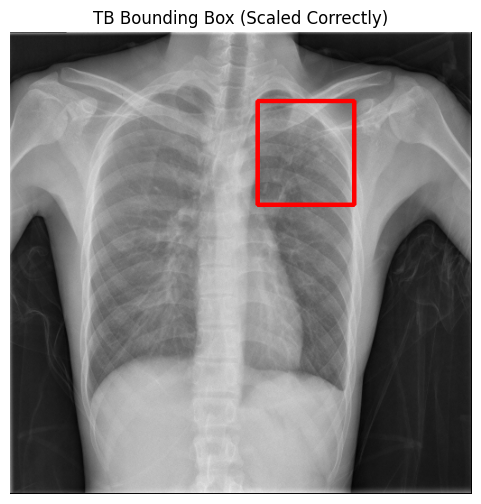

In [14]:


# Paths
img_path = "/kaggle/input/tbx-11/TBX11K/imgs/tb/tb0329.png"
xml_path = "/kaggle/input/tbx-11/TBX11K/annotations/xml/tb0329.xml"

# Load resized image
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w, _ = img.shape

# Parse XML
tree = ET.parse(xml_path)
root = tree.getroot()

# Get original annotation size
size = root.find("size")
orig_w = int(size.find("width").text)
orig_h = int(size.find("height").text)

scale_x = w / orig_w
scale_y = h / orig_h

print("Scale factors:", scale_x, scale_y)

# Draw scaled bounding boxes
for obj in root.findall("object"):
    bbox = obj.find("bndbox")
    xmin = int(int(bbox.find("xmin").text) * scale_x)
    ymin = int(int(bbox.find("ymin").text) * scale_y)
    xmax = int(int(bbox.find("xmax").text) * scale_x)
    ymax = int(int(bbox.find("ymax").text) * scale_y)

    cv2.rectangle(img_rgb, (xmin, ymin), (xmax, ymax), (255, 0, 0), 4)

# Show image
plt.figure(figsize=(6,6))
plt.imshow(img_rgb)
plt.title("TB Bounding Box (Scaled Correctly)")
plt.axis("off")
plt.show()


Dataset cleaning

In [15]:
import os

BASE_PATH = "/kaggle/input/tbx-11/TBX11K"

TRAIN_LIST = os.path.join(BASE_PATH, "lists/TBX11K_train.txt")
VAL_LIST   = os.path.join(BASE_PATH, "lists/TBX11K_val.txt")

with open(TRAIN_LIST) as f:
    train_ids = [line.strip() for line in f.readlines()]

with open(VAL_LIST) as f:
    val_ids = [line.strip() for line in f.readlines()]

print("Train images:", len(train_ids))
print("Val images:", len(val_ids))
print("Sample train IDs:", train_ids[:5])
print("Sample val IDs:", val_ids[:5])


Train images: 6600
Val images: 1800
Sample train IDs: ['tb/tb0005.png', 'tb/tb0007.png', 'tb/tb0012.png', 'tb/tb0017.png', 'tb/tb0018.png']
Sample val IDs: ['tb/tb0003.png', 'tb/tb0004.png', 'tb/tb0006.png', 'tb/tb0009.png', 'tb/tb0014.png']


In [17]:
import os
import xml.etree.ElementTree as ET

BASE_PATH = "/kaggle/input/tbx-11/TBX11K"
IMG_DIR = os.path.join(BASE_PATH, "imgs")
XML_DIR = os.path.join(BASE_PATH, "annotations/xml")

def analyze_ids(id_list):
    stats = {
        "total": 0,
        "tb_with_xml": 0,
        "tb_missing_xml": 0,
        "normal": 0,
        "missing_image": 0,
        "multi_lesion": 0
    }

    for rel_path in id_list:
        stats["total"] += 1

        # rel_path example: tb/tb0005.png
        img_path = os.path.join(IMG_DIR, rel_path)

        if not os.path.exists(img_path):
            stats["missing_image"] += 1
            continue

        filename = os.path.basename(rel_path)       # tb0005.png
        img_id = os.path.splitext(filename)[0]      # tb0005

        # TB case
        if rel_path.startswith("tb/"):
            xml_path = os.path.join(XML_DIR, img_id + ".xml")

            if os.path.exists(xml_path):
                stats["tb_with_xml"] += 1

                tree = ET.parse(xml_path)
                root = tree.getroot()
                objs = root.findall("object")
                if len(objs) > 1:
                    stats["multi_lesion"] += 1
            else:
                stats["tb_missing_xml"] += 1

        # Normal case
        elif rel_path.startswith("health/"):
            stats["normal"] += 1

    return stats


print("TRAIN STATS:", analyze_ids(train_ids))
print("VAL STATS:", analyze_ids(val_ids))


TRAIN STATS: {'total': 6600, 'tb_with_xml': 600, 'tb_missing_xml': 0, 'normal': 3000, 'missing_image': 0, 'multi_lesion': 281}
VAL STATS: {'total': 1800, 'tb_with_xml': 200, 'tb_missing_xml': 0, 'normal': 800, 'missing_image': 0, 'multi_lesion': 101}


Creating Yolo Directory TO train the model

In [18]:
import os

YOLO_BASE = "/kaggle/working/tb_yolo"

for split in ["train", "val"]:
    os.makedirs(os.path.join(YOLO_BASE, "images", split), exist_ok=True)
    os.makedirs(os.path.join(YOLO_BASE, "labels", split), exist_ok=True)

print("YOLO directory structure created")


YOLO directory structure created


XML -> Yolo Conversion

In [20]:
import xml.etree.ElementTree as ET
import cv2

BASE_PATH = "/kaggle/input/tbx-11/TBX11K"
IMG_DIR = os.path.join(BASE_PATH, "imgs")
XML_DIR = os.path.join(BASE_PATH, "annotations/xml")

def convert_xml_to_yolo(rel_img_path, split):
    """
    rel_img_path example: tb/tb0329.png or health/h3703.png
    """
    img_src = os.path.join(IMG_DIR, rel_img_path)
    img_dst = os.path.join(YOLO_BASE, "images", split, os.path.basename(rel_img_path))

    # Copy image
    img = cv2.imread(img_src)
    if img is None:
        return
    cv2.imwrite(img_dst, img)

    label_path = os.path.join(
        YOLO_BASE, "labels", split,
        os.path.splitext(os.path.basename(rel_img_path))[0] + ".txt"
    )

    # Normal image → empty label file
    if rel_img_path.startswith("health/"):
        open(label_path, "w").close()
        return

    # TB image → parse XML
    img_id = os.path.splitext(os.path.basename(rel_img_path))[0]
    xml_path = os.path.join(XML_DIR, img_id + ".xml")

    if not os.path.exists(xml_path):
        open(label_path, "w").close()
        return

    tree = ET.parse(xml_path)
    root = tree.getroot()

    # Original annotation size
    size = root.find("size")
    orig_w = int(size.find("width").text)
    orig_h = int(size.find("height").text)

    # Current image size
    h, w, _ = img.shape

    scale_x = w / orig_w
    scale_y = h / orig_h

    with open(label_path, "w") as f:
        for obj in root.findall("object"):
            bbox = obj.find("bndbox")

            xmin = int(int(bbox.find("xmin").text) * scale_x)
            ymin = int(int(bbox.find("ymin").text) * scale_y)
            xmax = int(int(bbox.find("xmax").text) * scale_x)
            ymax = int(int(bbox.find("ymax").text) * scale_y)

            # YOLO format (normalized)
            x_center = ((xmin + xmax) / 2) / w
            y_center = ((ymin + ymax) / 2) / h
            box_w = (xmax - xmin) / w
            box_h = (ymax - ymin) / h

            f.write(f"0 {x_center} {y_center} {box_w} {box_h}\n")


In [21]:
for rel_path in train_ids:
    convert_xml_to_yolo(rel_path, "train")

for rel_path in val_ids:
    convert_xml_to_yolo(rel_path, "val")

print("Conversion completed")


Conversion completed


Creating Data.Yaml 

In [22]:
data_yaml = f"""
path: {YOLO_BASE}
train: images/train
val: images/val

nc: 1
names: ['ActiveTuberculosis']
"""

with open(os.path.join(YOLO_BASE, "data.yaml"), "w") as f:
    f.write(data_yaml)

print("data.yaml created")


data.yaml created


Total train images: 6600
Sample images: ['h0001.png', 'h0003.png', 'h0005.png', 'h0008.png', 'h0009.png']
Using sample: tb0005.png


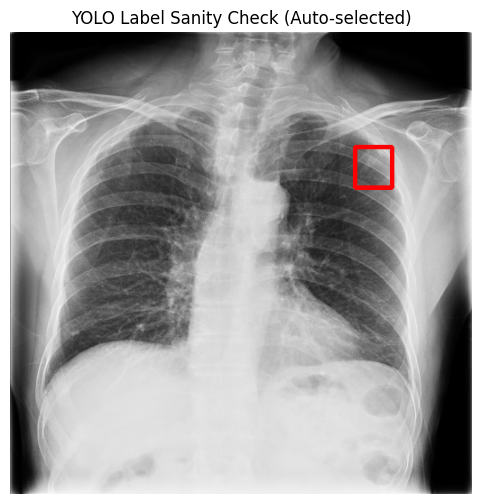

In [24]:
import os
import cv2
import matplotlib.pyplot as plt

# List available train images
train_img_dir = os.path.join(YOLO_BASE, "images/train")
train_lbl_dir = os.path.join(YOLO_BASE, "labels/train")

imgs = sorted(os.listdir(train_img_dir))
print("Total train images:", len(imgs))
print("Sample images:", imgs[:5])

# Pick first TB image (starts with 'tb')
sample_img = next(img for img in imgs if img.startswith("tb"))
sample_lbl = sample_img.replace(".png", ".txt")

print("Using sample:", sample_img)

img_path = os.path.join(train_img_dir, sample_img)
lbl_path = os.path.join(train_lbl_dir, sample_lbl)

# Load image
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w, _ = img.shape

# Draw YOLO boxes
with open(lbl_path) as f:
    for line in f.readlines():
        cls, xc, yc, bw, bh = map(float, line.split())

        xmin = int((xc - bw/2) * w)
        ymin = int((yc - bh/2) * h)
        xmax = int((xc + bw/2) * w)
        ymax = int((yc + bh/2) * h)

        cv2.rectangle(img, (xmin, ymin), (xmax, ymax), (255, 0, 0), 3)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title("YOLO Label Sanity Check (Auto-selected)")
plt.axis("off")
plt.show()


In [25]:
!pip install -q ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.0 MB/s eta 0:00:00a 0:00:01


Model Training

In [26]:
from ultralytics import YOLO
print("YOLOv8 ready")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLOv8 ready


In [27]:
model = YOLO("yolov8s.pt")

model.train(
    data="/kaggle/working/tb_yolo/data.yaml",
    epochs=50,
    imgsz=512,
    batch=16,
    workers=4,
    project="tb_yolo_runs",
    name="yolov8s_tb",
    patience=10,
    device=0
)


Ultralytics 8.4.9 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/tb_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s_tb, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, perspect

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c4f5a28dd90>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

Infernece & Visualization

In [28]:
from ultralytics import YOLO

MODEL_PATH = "/kaggle/working/runs/detect/tb_yolo_runs/yolov8s_tb/weights/best.pt"
model = YOLO(MODEL_PATH)

print("Model loaded successfully")


Model loaded successfully


In [41]:
import random
import cv2
import matplotlib.pyplot as plt
import os

VAL_IMG_DIR = "/kaggle/working/tb_yolo/images/val"
CONF_TH = 0.25

# Pick random samples
all_imgs = os.listdir(VAL_IMG_DIR)
tb_imgs = [img for img in all_imgs if img.startswith("tb")]
normal_imgs = [img for img in all_imgs if img.startswith("h")]

sample_imgs = random.sample(tb_imgs, 3) + random.sample(normal_imgs, 3)

print("Samples:", sample_imgs)


Samples: ['tb0918.png', 'tb0446.png', 'tb1124.png', 'h0791.png', 'h2303.png', 'h4219.png']


In [42]:
def visualize_prediction(img_name):
    img_path = os.path.join(VAL_IMG_DIR, img_name)
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    results = model(img_path)[0]

    for box in results.boxes:
        conf = float(box.conf[0])
        if conf < CONF_TH:
            continue

        x1, y1, x2, y2 = map(int, box.xyxy[0])
        label = f"TB {conf:.2f}"

        cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (255, 0, 0), 3)
        cv2.putText(
            img_rgb, label,
            (x1, y1 - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (255, 0, 0),
            2
        )

    plt.figure(figsize=(5,5))
    plt.imshow(img_rgb)
    plt.title(img_name)
    plt.axis("off")
    plt.show()



image 1/1 /kaggle/working/tb_yolo/images/val/tb0918.png: 512x512 2 ActiveTuberculosiss, 11.1ms
Speed: 1.3ms preprocess, 11.1ms inference, 1.4ms postprocess per image at shape (1, 3, 512, 512)


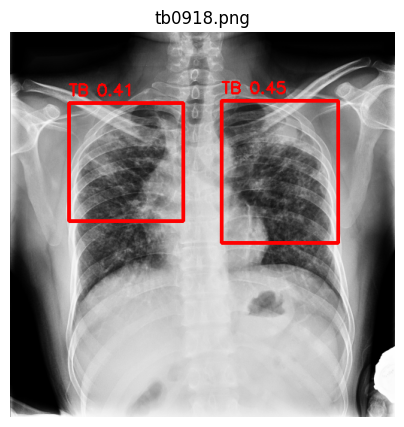


image 1/1 /kaggle/working/tb_yolo/images/val/tb0446.png: 512x512 1 ActiveTuberculosis, 11.0ms
Speed: 1.0ms preprocess, 11.0ms inference, 1.2ms postprocess per image at shape (1, 3, 512, 512)


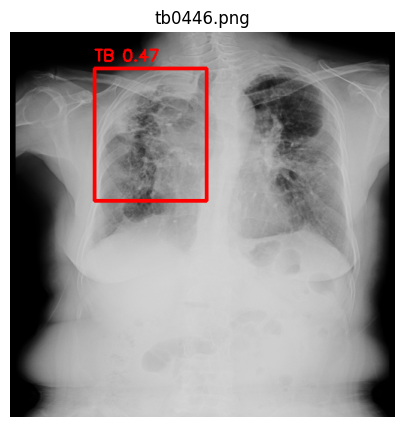


image 1/1 /kaggle/working/tb_yolo/images/val/tb1124.png: 512x512 1 ActiveTuberculosis, 11.0ms
Speed: 1.1ms preprocess, 11.0ms inference, 1.3ms postprocess per image at shape (1, 3, 512, 512)


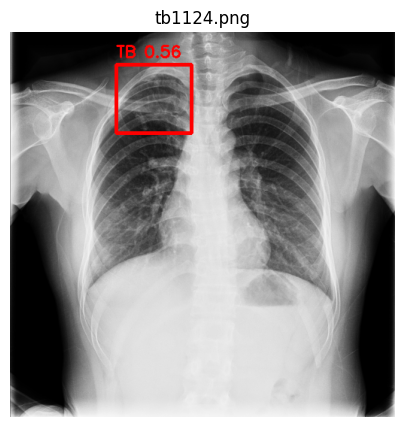


image 1/1 /kaggle/working/tb_yolo/images/val/h0791.png: 512x512 (no detections), 11.0ms
Speed: 0.9ms preprocess, 11.0ms inference, 0.5ms postprocess per image at shape (1, 3, 512, 512)


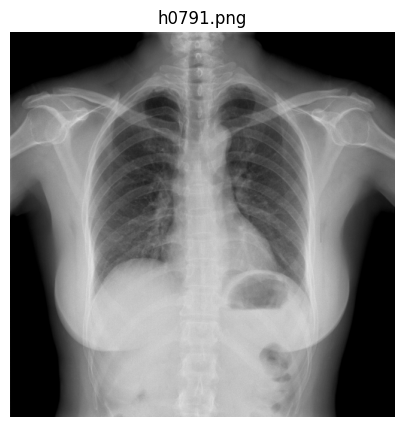


image 1/1 /kaggle/working/tb_yolo/images/val/h2303.png: 512x512 (no detections), 11.0ms
Speed: 1.1ms preprocess, 11.0ms inference, 0.7ms postprocess per image at shape (1, 3, 512, 512)


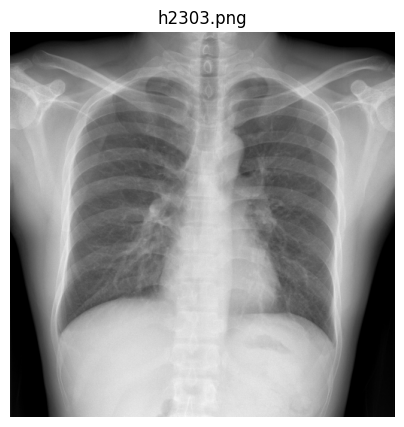


image 1/1 /kaggle/working/tb_yolo/images/val/h4219.png: 512x512 (no detections), 11.0ms
Speed: 0.9ms preprocess, 11.0ms inference, 0.6ms postprocess per image at shape (1, 3, 512, 512)


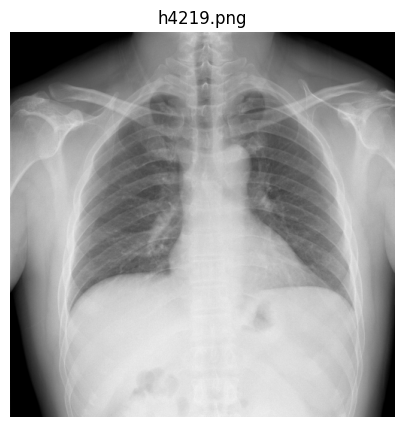

In [43]:
for img in sample_imgs:
    visualize_prediction(img)
